In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [8]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

In [10]:
# 1.Data cleaning
# 2.EDA
# 3.Text Preprocessing
# 4.Model Building
# 5.Evaluation
# 6.Improvement
# 7.Website
# 8.Deploy

**1.Data Cleaning**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [13]:
# renaming cols
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [14]:
df.sample(5)

,target,text
3639,ham,He's really into skateboarding now despite the...
3895,spam,tells u 2 call 09066358152 to claim å£5000 pri...
1087,ham,You can never do NOTHING
1869,ham,Mom wants to know where you at
1392,ham,"Thk shld b can... Ya, i wana go 4 lessons... H..."


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [16]:
#lable encoder
df["target"] = encoder.fit_transform(df['target'])

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.isnull().sum()

,0
target,0
text,0


In [19]:
df.duplicated().sum()

np.int64(403)

In [20]:
# remove dupliactes
df = df.drop_duplicates(keep='first')

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(5169, 2)

**2.EDA**

In [23]:
# kitne percent spam h kitne nahi
df['target'].value_counts()

,count
target,
0,4516
1,653


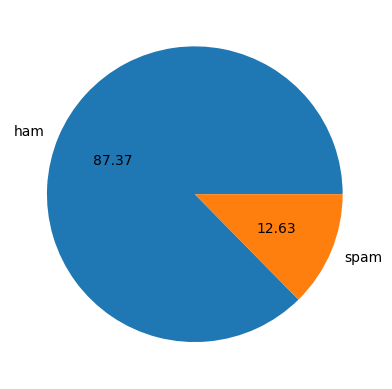

In [24]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [25]:
# data is imbalance

In [26]:
!pip install nltk

In [27]:
import nltk

In [28]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [29]:
# no of char
df['num_char'] = df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [30]:
# no of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [31]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [32]:
df['num_sen'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [33]:
df.head()

,target,text,num_char,num_words,num_sen
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [34]:
df[['num_char', 'num_words', 'num_sen']].describe()

,num_char,num_words,num_sen
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
# ham messages
df[df['target']==0][['num_char' , 'num_words' , 'num_sen']].describe()

,num_char,num_words,num_sen
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [36]:
# spam messages
df[df['target']==1][['num_char' , 'num_words' , 'num_sen']].describe()

,num_char,num_words,num_sen
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [37]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

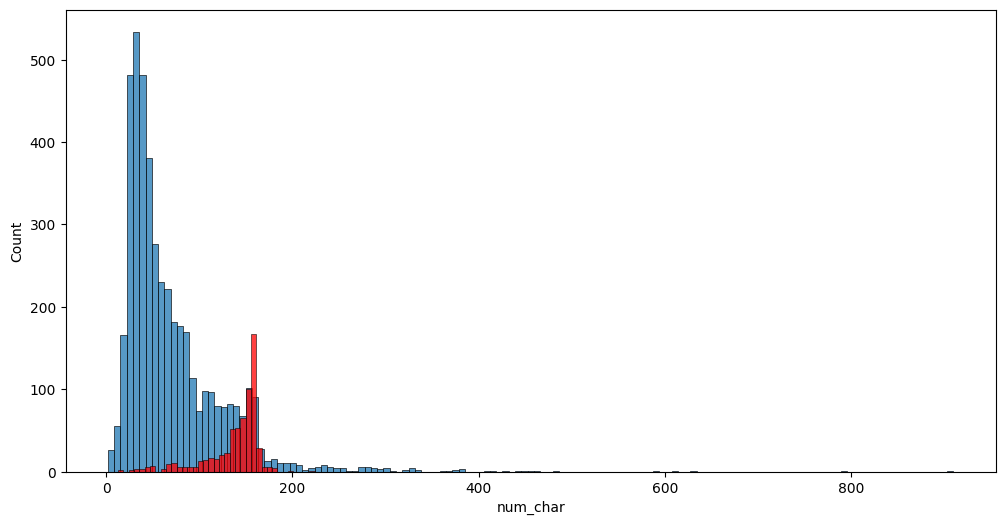

In [38]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Figure size 2000x800 with 0 Axes>

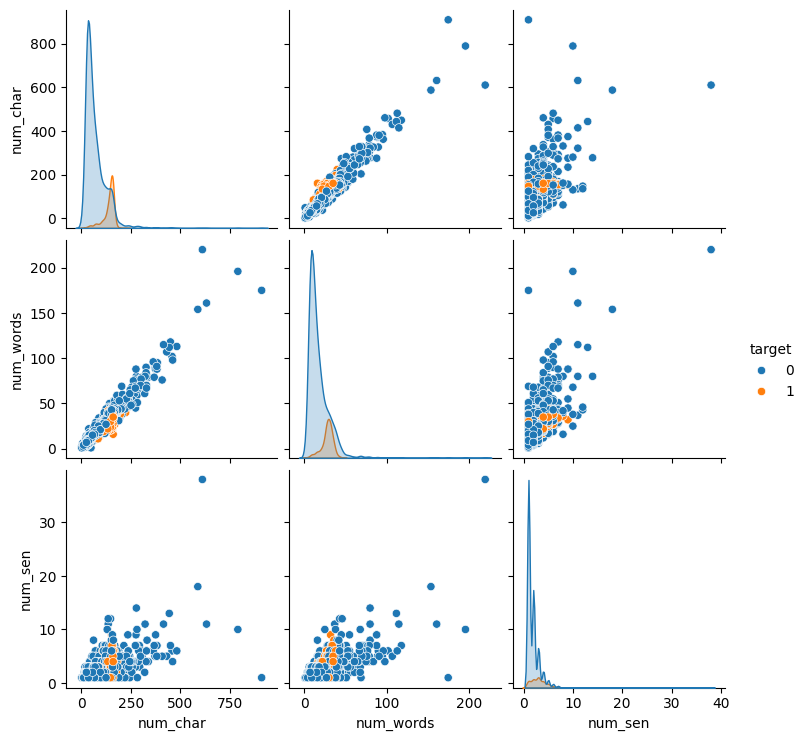

In [40]:
plt.figure(figsize=(20,8))
sns.pairplot(df , hue='target')

<Axes: >

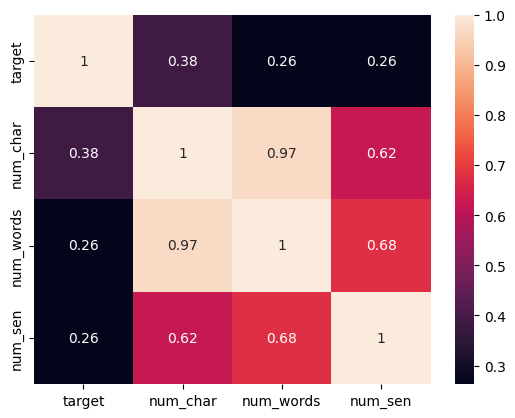

In [41]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

**3.Data Preprocessing**


*   lowercase
*   tokenization
*   remove special char
*   remove stop words and punctuation
*   stemming



In [42]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [43]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [44]:
stop_words = set(stopwords.words('english'))

def transformText(text):
    text = text.lower()
    words = nltk.word_tokenize(text)

    # remove non-alphanumeric
    words = [w for w in words if w.isalnum()]

    # remove stopwords
    words = [w for w in words if w not in stop_words]

    # stemming
    words = [ps.stem(w) for w in words]

    return " ".join(words)

In [45]:
df['transformedText'] = df['text'].apply(transformText)

In [46]:
df.head()

,target,text,num_char,num_words,num_sen,transformedText
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [47]:
!pip install wordcloud

In [48]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='black')

In [49]:
spam_wc = wc.generate(df[df['target'] == 1]['transformedText'].str.cat(sep=" "))

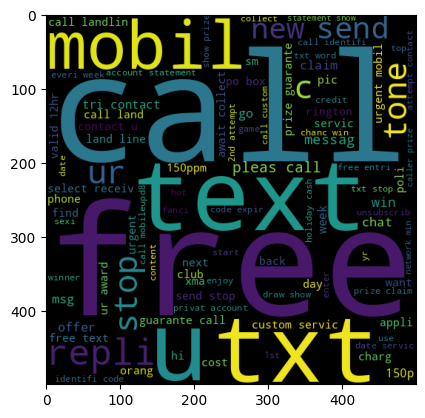

In [50]:
plt.imshow(spam_wc)

In [51]:
ham_wc = wc.generate(df[df['target'] == 0]['transformedText'].str.cat(sep=" "))

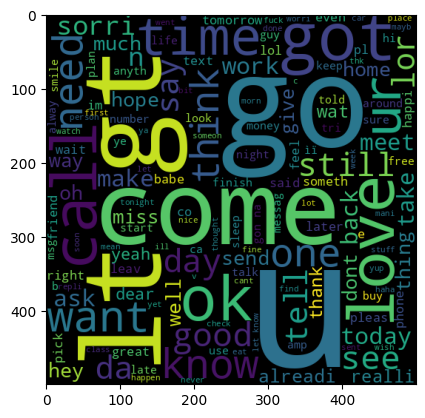

In [52]:
plt.imshow(ham_wc)

**4.Model Building**

In [53]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [83]:
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [55]:
X = cv.fit_transform(df['transformedText']).toarray()

In [58]:
X.shape

(5169, 6708)

In [59]:
Y = df["target"].values

In [61]:
Y.shape

(5169,)

In [65]:
from sklearn.model_selection import train_test_split

In [67]:
X_train , X_test , Y_train , y_test = train_test_split(X , Y ,test_size=0.2, random_state=52)

In [69]:
X_train.shape

(4135, 6708)

In [71]:
from sklearn.naive_bayes import MultinomialNB , BernoulliNB , GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [74]:
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb = GaussianNB()

In [79]:
gnb.fit(X_train , Y_train)
ypred1 = (gnb.predict(X_test))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.8752417794970987
[[787 115]
 [ 14 118]]
0.5064377682403434


In [80]:
mnb.fit(X_train , Y_train)
ypred1 = (mnb.predict(X_test))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.9748549323017408
[[883  19]
 [  7 125]]
0.8680555555555556


In [81]:
bnb.fit(X_train , Y_train)
ypred1 = (bnb.predict(X_test))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.9632495164410058
[[896   6]
 [ 32 100]]
0.9433962264150944


In [84]:
X_tfidf = tfidf.fit_transform(df['transformedText']).toarray()

In [85]:
X_train_tfidf , X_test_tfidf , Y_train , y_test = train_test_split(X_tfidf , Y ,test_size=0.2, random_state=52)

In [86]:
gnb.fit(X_train_tfidf , Y_train)
ypred1 = (gnb.predict(X_test_tfidf))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.8704061895551257
[[785 117]
 [ 17 115]]
0.4956896551724138


In [87]:
mnb.fit(X_train_tfidf , Y_train)
ypred1 = (mnb.predict(X_test_tfidf))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.9758220502901354
[[902   0]
 [ 25 107]]
1.0


In [88]:
bnb.fit(X_train_tfidf , Y_train)
ypred1 = (bnb.predict(X_test_tfidf))
print(accuracy_score(y_test , ypred1))
print(confusion_matrix(y_test , ypred1))
print(precision_score(y_test , ypred1))

0.9748549323017408
[[897   5]
 [ 21 111]]
0.9568965517241379


In [89]:
#we will take the mnb model as in the specific project the precision of the model matters more than the accuracy of the model and wwith tfidf the mnb is giving no TurePositive hence we select mnb model

In [90]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))